# Historical Behavioural Classification (2019-2020)
**Goal:** 
To run our strict `BehaviouralClassifier` engine over 2 years of historical data (prior to 2021) across 25 stocks. We will chop the history into blocks, classify each block using our new Target-Relative rules, and plot the visual grids to verify the edge.


In [1]:

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob
from behavioural_classifier import BehaviouralClassifier

# 1. Configuration
classifier = BehaviouralClassifier(target_pct=5.0, target_days=13, regime_lookback=26)
BLOCK_SIZE = 26
WARMUP_DAYS = 250 # Increased to 250 to allow Omega PR (200 lookback + period) calculation

def calc_omega_pr(series, period, lookback=200):
    daily_returns = series.pct_change()
    def get_omega(ret_window):
        gains = ret_window[ret_window > 0].sum()
        losses = abs(ret_window[ret_window < 0].sum())
        if losses == 0: 
            return gains / 0.0001 if gains > 0 else 1.0
        return gains / losses
    rolling_omega = daily_returns.rolling(period).apply(get_omega, raw=False)
    pr = rolling_omega.rolling(lookback).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False)
    return pr


DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:25] # 25 Stocks

# 2. Historical Block Processing
results = []

for file_path in all_files:
    try:
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        
        # Filter for 2 years of data before 2021 (2019-01-01 to 2020-12-31)
        df = df[(df['Date'] >= '2018-09-01') & (df['Date'] <= '2020-12-31')].reset_index(drop=True)
        
        if len(df) < WARMUP_DAYS + BLOCK_SIZE: continue
        
        stock_name = os.path.basename(file_path).split('.')[0]
        
        # Chop into blocks, but we step forward by BLOCK_SIZE and pass the trailing WARMUP_DAYS to the engine
        num_blocks = (len(df) - WARMUP_DAYS) // BLOCK_SIZE
        
        for i in range(num_blocks):
            end_idx = WARMUP_DAYS + (i * BLOCK_SIZE)
            start_idx = end_idx - WARMUP_DAYS
            
            # The chunk passed to the classifier ends precisely at the end of this block
            chunk = df.iloc[start_idx:end_idx].copy()
            
            # The actual block is just the last BLOCK_SIZE days of the chunk
            actual_block = chunk.iloc[-BLOCK_SIZE:].copy()
            block_start_date = actual_block['Date'].iloc[0]
            
            group_label, metrics = classifier.classify_block(chunk)
            
            if metrics: # If it didn't fail the anomaly/data checks instantly
                results.append({
                    'Stock': stock_name,
                    'Date': block_start_date,
                    'Group': group_label,
                    'Hit_Rate': metrics.get('Hit_Rate', 0),
                    'Volatility': metrics.get('Daily_Volatility', 0)
                })
    except Exception as e:
        pass

df_results = pd.DataFrame(results)
print(f"Total valid blocks processed: {len(df_results)}")
print(df_results['Group'].value_counts())


Total valid blocks processed: 135
Group
BLACKLIST_UNFAVORABLE         114
GROUP_2_AGGRESSIVE_CLIMBER     12
GROUP_3_SAFE_GRINDER            7
GROUP_1_HOLY_GRAIL              2
Name: count, dtype: int64


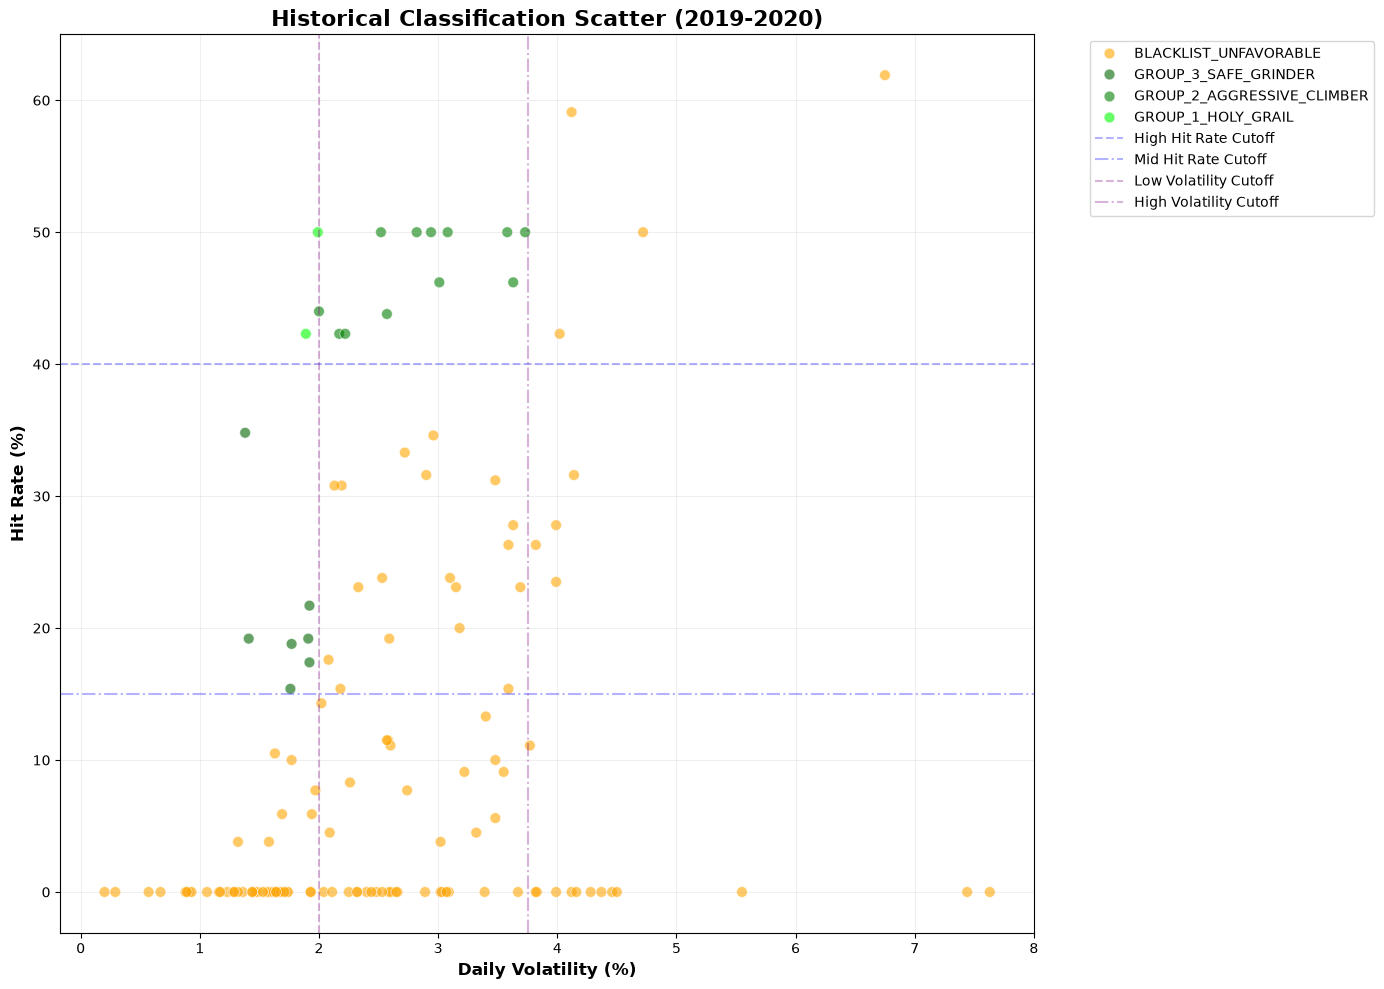

In [2]:

# 3. Scatter Plot of the Results
plt.figure(figsize=(14, 10))

# We map colors manually so the good groups pop
color_map = {
    'GROUP_1_HOLY_GRAIL': 'lime',
    'GROUP_2_AGGRESSIVE_CLIMBER': 'green',
    'GROUP_3_SAFE_GRINDER': 'darkgreen',
    'BLACKLIST_NO_TREND': 'red',
    'BLACKLIST_UNFAVORABLE': 'orange',
    'BLACKLIST_ANOMALY': 'black'
}

sns.scatterplot(
    data=df_results,
    x='Volatility',
    y='Hit_Rate',
    hue='Group',
    palette=color_map,
    s=60,
    alpha=0.6
)

plt.axhline(40, color='blue', linestyle='--', alpha=0.3, label='High Hit Rate Cutoff')
plt.axhline(15, color='blue', linestyle='-.', alpha=0.3, label='Mid Hit Rate Cutoff')
plt.axvline(2.0, color='purple', linestyle='--', alpha=0.3, label='Low Volatility Cutoff')
plt.axvline(3.75, color='purple', linestyle='-.', alpha=0.3, label='High Volatility Cutoff')

plt.title('Historical Classification Scatter (2019-2020)', fontsize=16, weight='bold')
plt.xlabel('Daily Volatility (%)', fontsize=12, weight='bold')
plt.ylabel('Hit Rate (%)', fontsize=12, weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


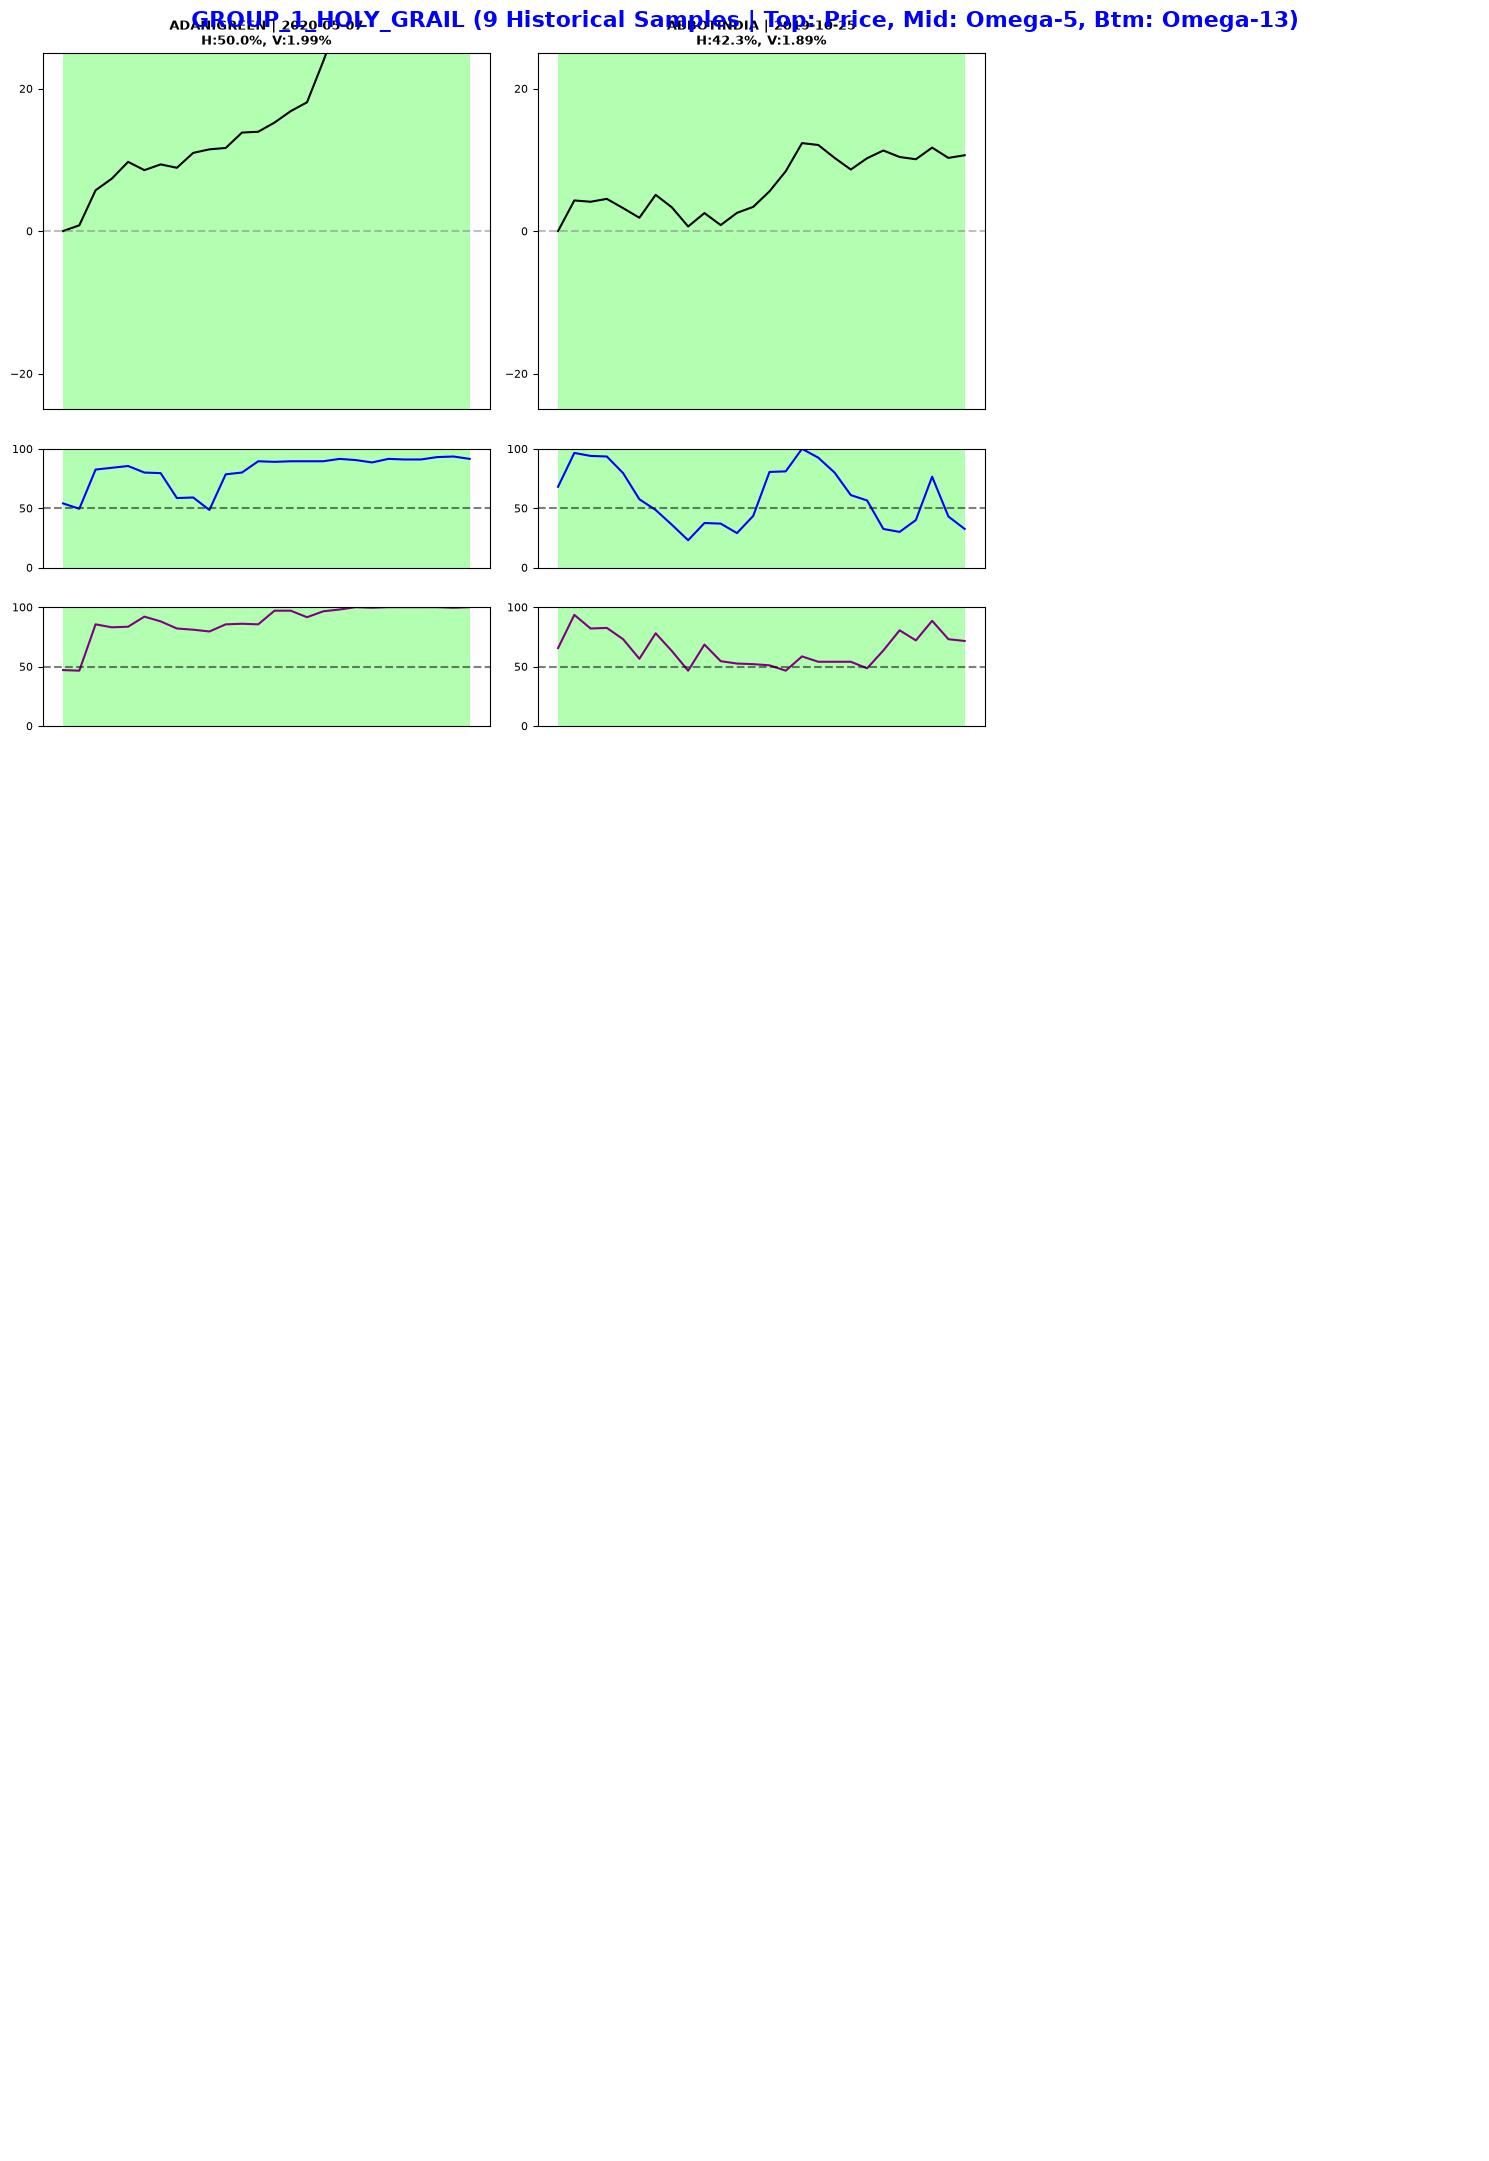

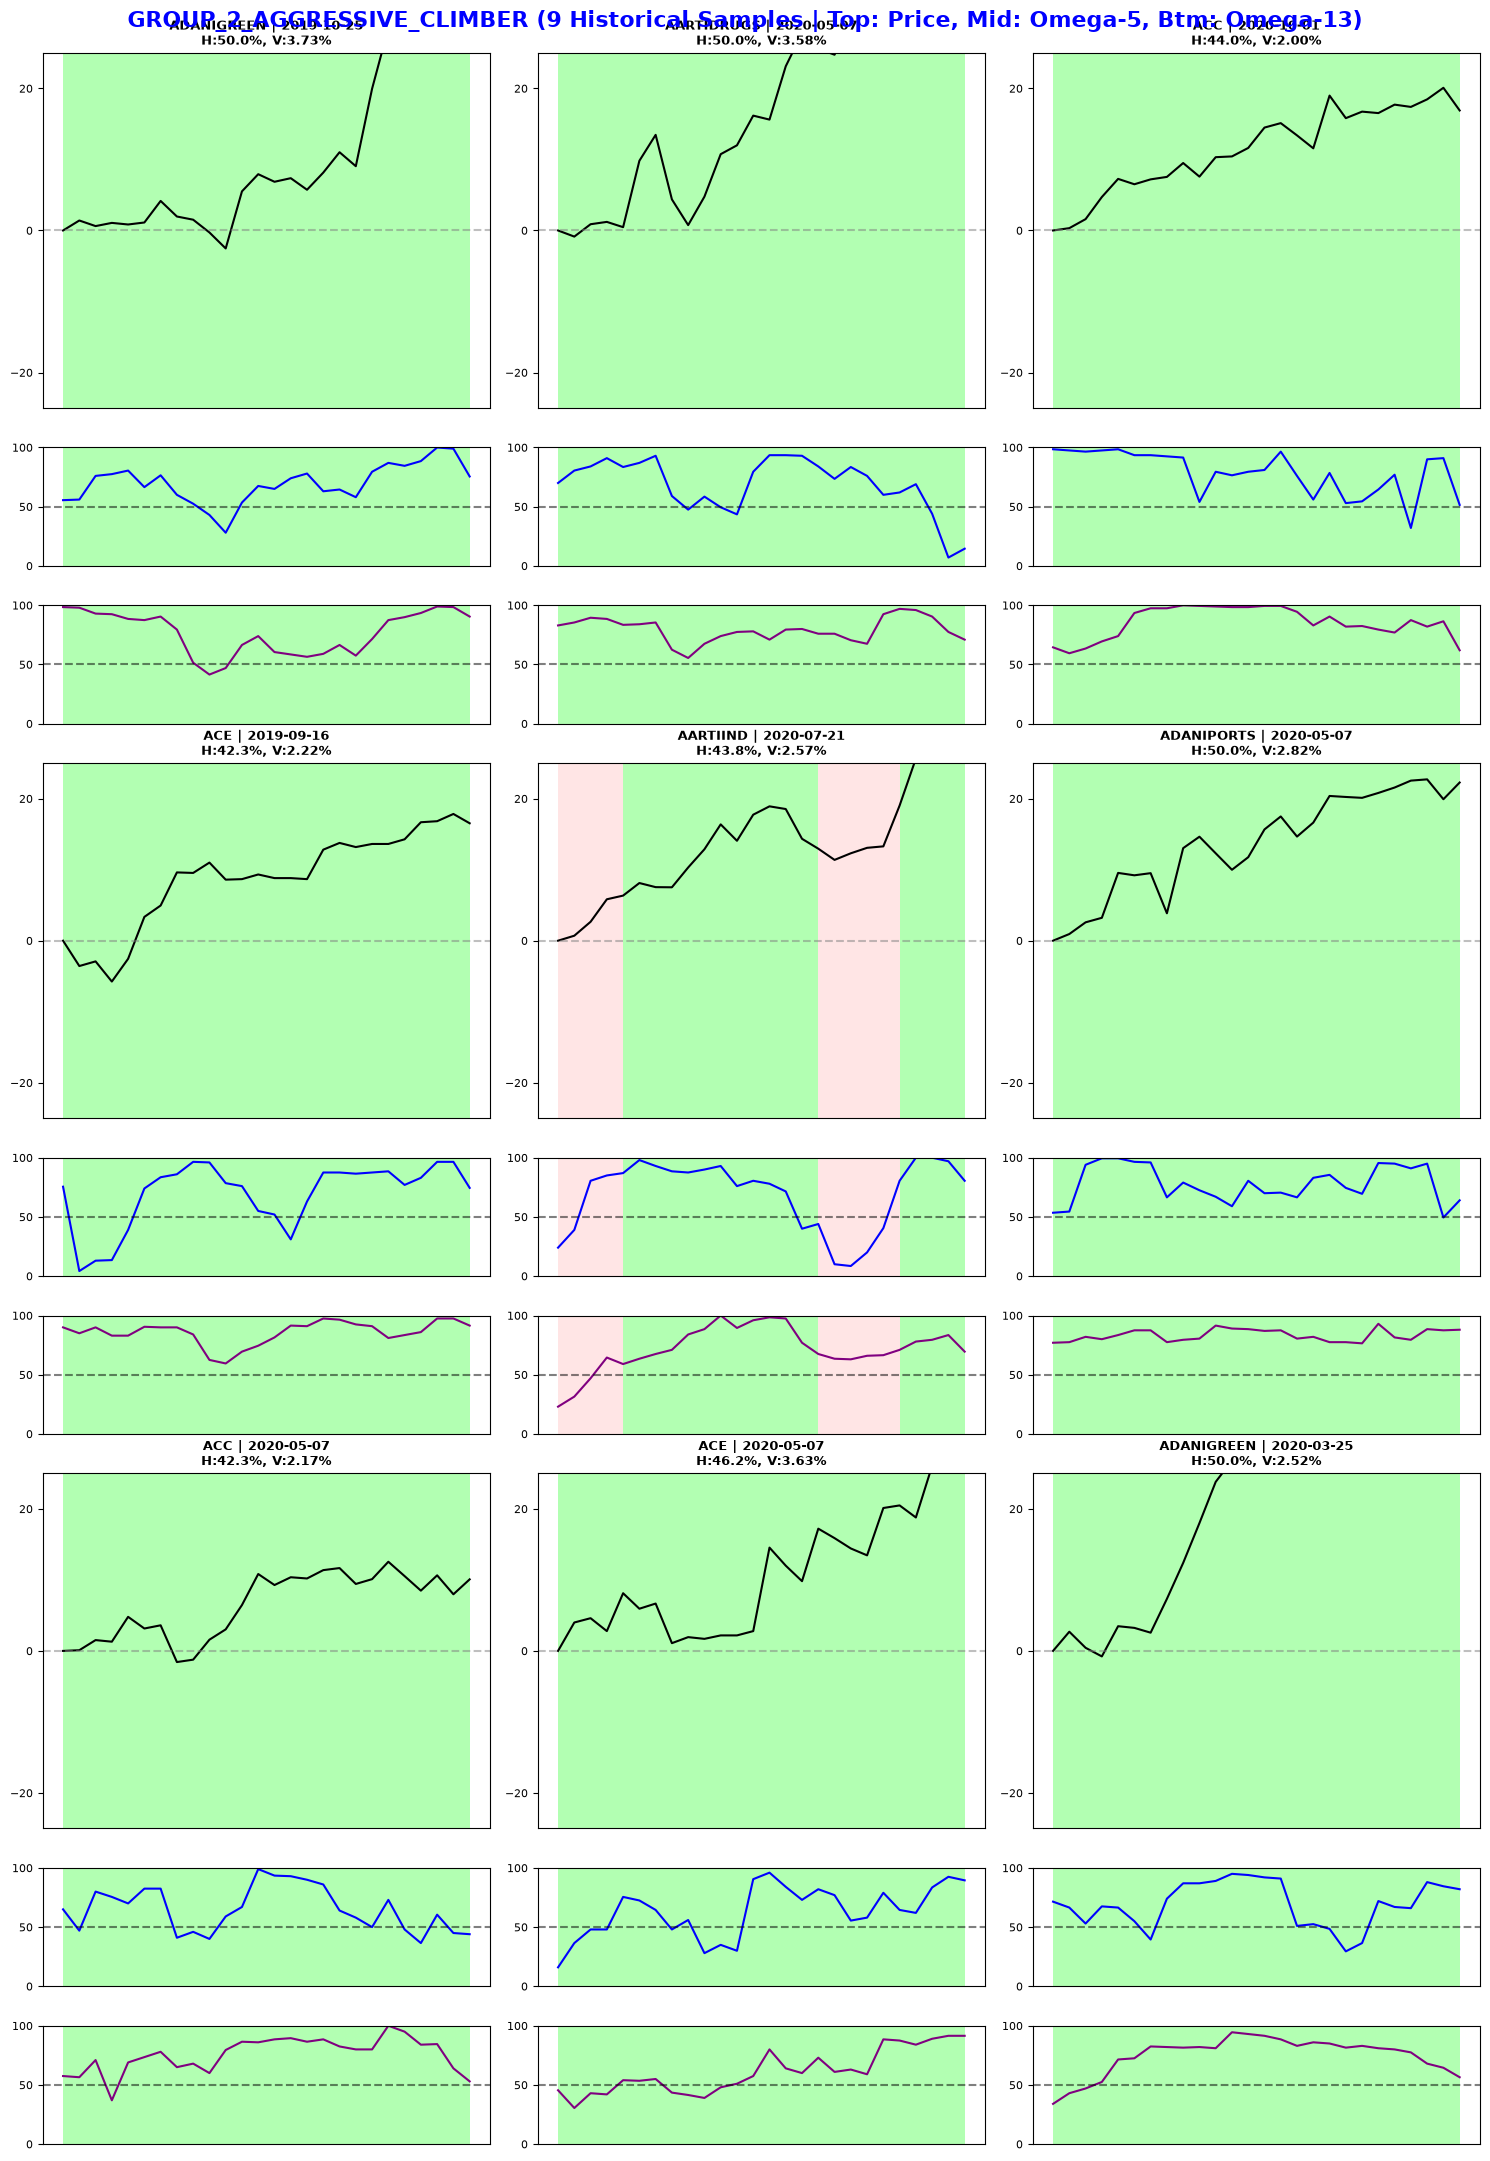

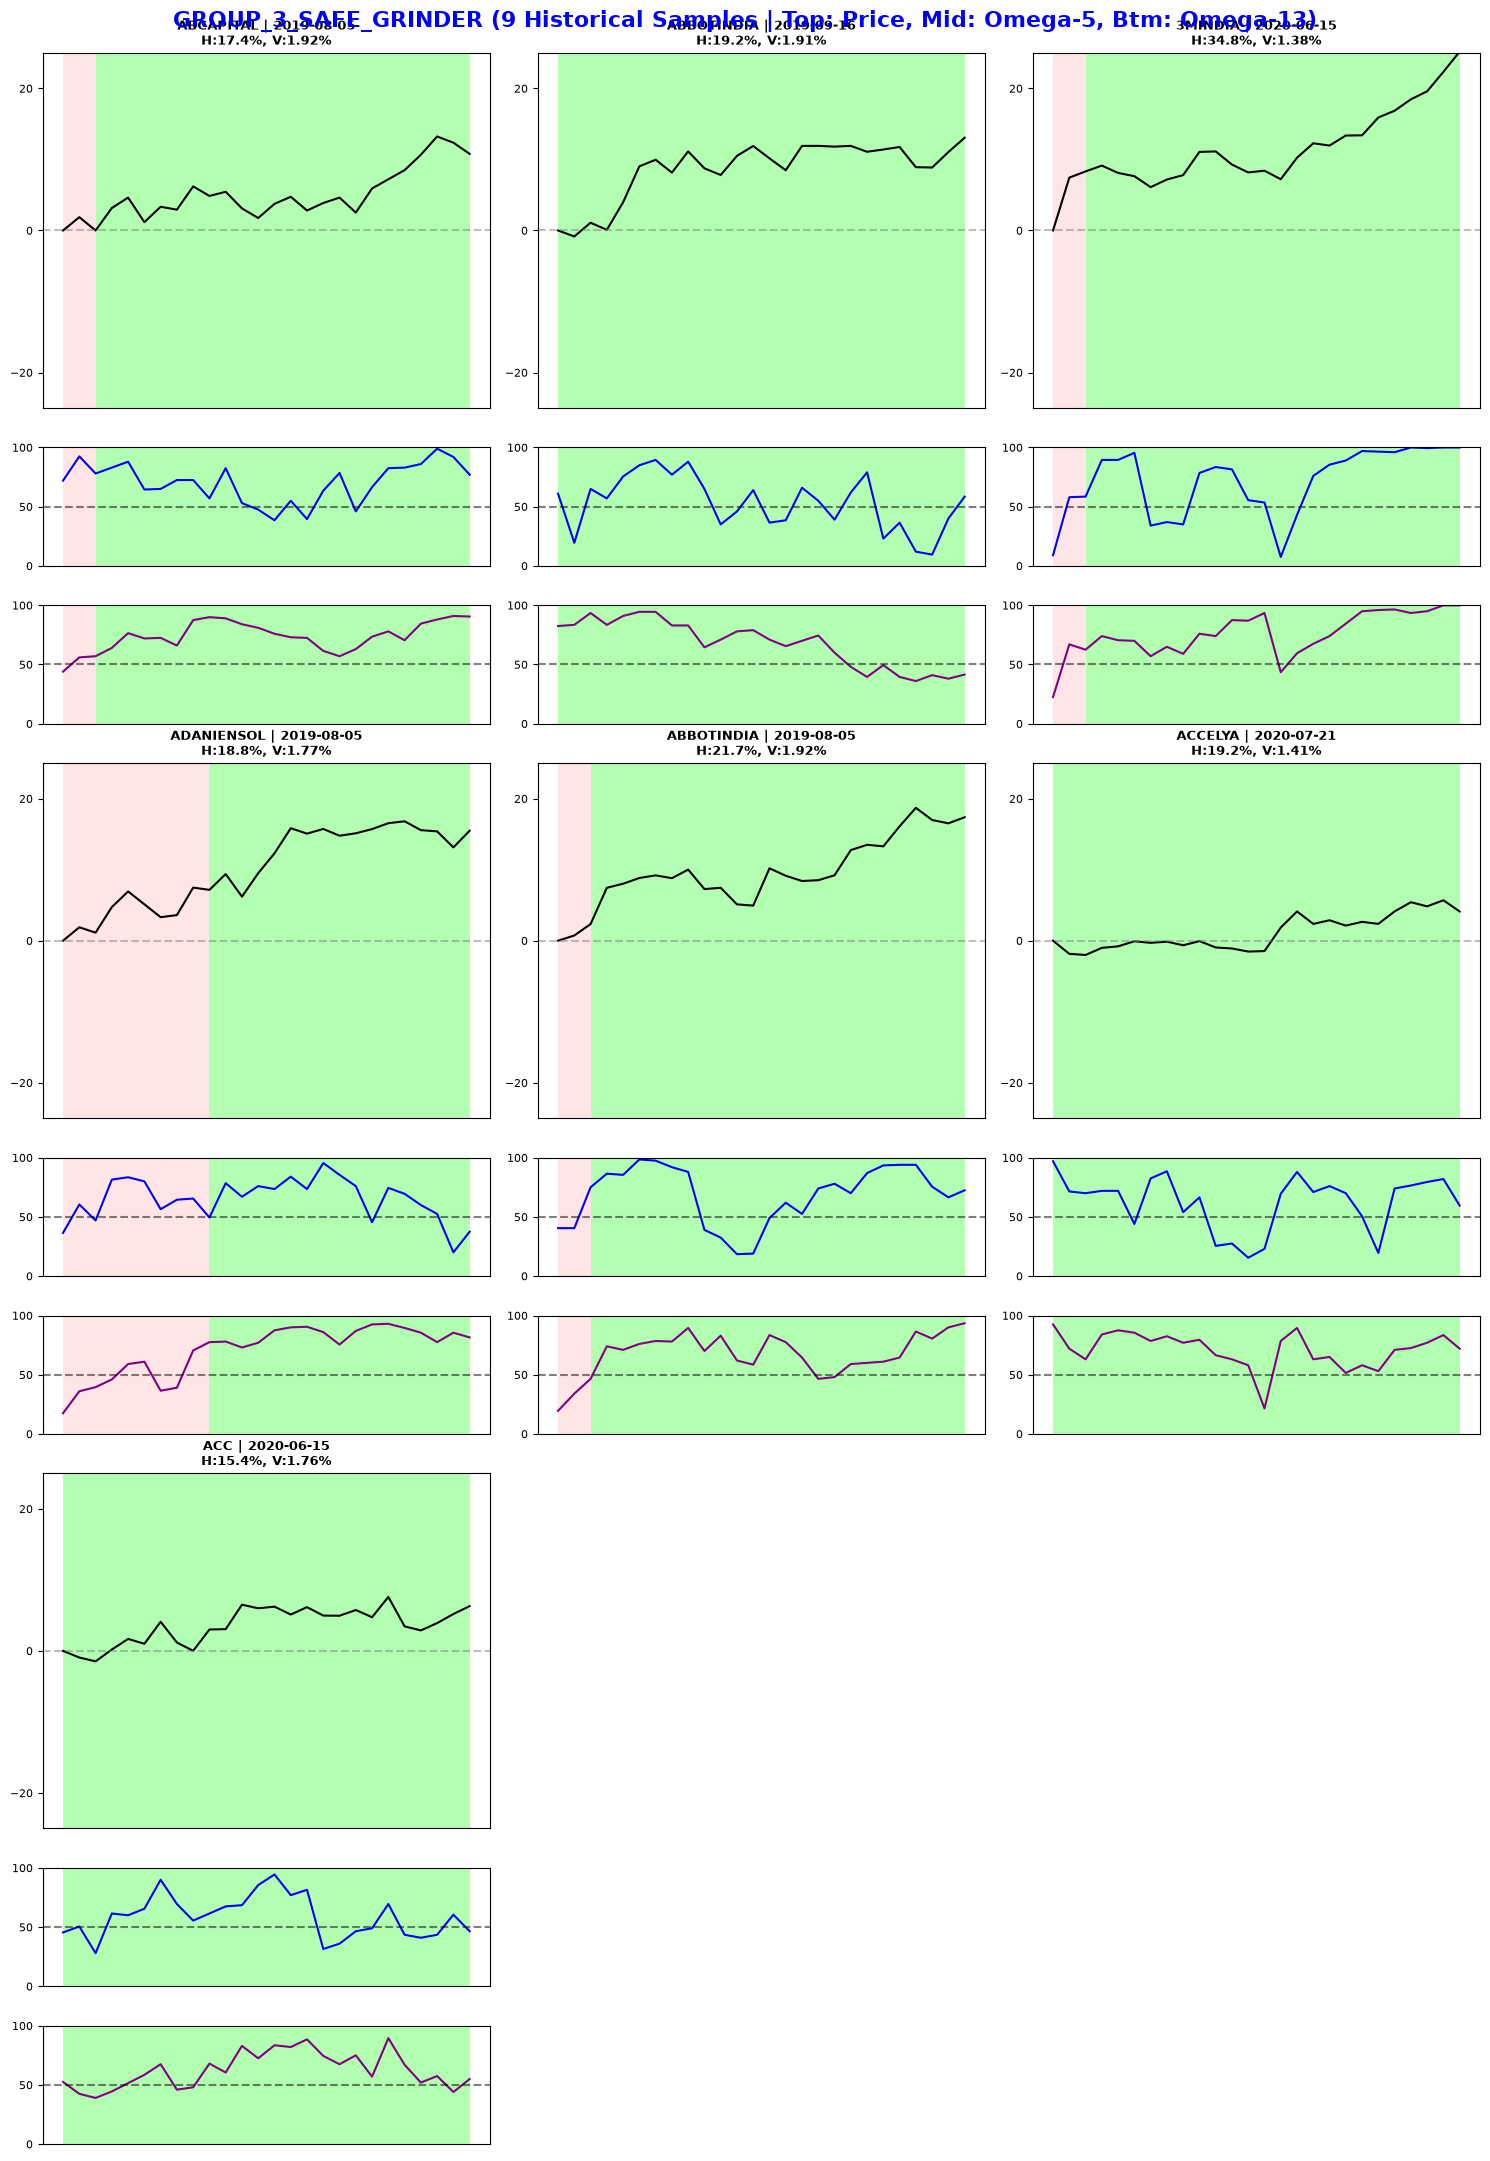

In [3]:

# 4. VISUALIZE REPRESENTATIVE BLOCKS FROM THE EDGE GROUPS
def plot_sample_block(row, ax_price, ax_omega5, ax_omega13):
    stock = row['Stock']
    target_date = row['Date']
    hit = row['Hit_Rate']
    vol = row['Volatility']
    
    file_path = os.path.join(DATA_DIR, f"{stock}.csv")
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Re-extract the block context
    idx = df[df['Date'] == target_date].index[0]
    chunk = df.iloc[idx - WARMUP_DAYS + BLOCK_SIZE : idx + BLOCK_SIZE].copy()
    
    st_trend = classifier.calc_supertrend(chunk)[-BLOCK_SIZE:]
    chunk['Omega_5'] = calc_omega_pr(chunk['Close'], 5)
    chunk['Omega_13'] = calc_omega_pr(chunk['Close'], 13)
    
    block = chunk.iloc[-BLOCK_SIZE:].copy()
    
    # Normalize to % change
    start_price = block['Close'].iloc[0]
    block_pct = ((block['Close'] / start_price) - 1) * 100
    
    ax_price.plot(range(len(block)), block_pct, color='black', lw=1.5)
    ax_price.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    for i in range(1, len(block)):
        if st_trend[i] == 1:
            ax_price.axvspan(i-1, i, color='lime', alpha=0.3, lw=0)
            ax_omega5.axvspan(i-1, i, color='lime', alpha=0.3, lw=0)
            ax_omega13.axvspan(i-1, i, color='lime', alpha=0.3, lw=0)
        else:
            ax_price.axvspan(i-1, i, color='red', alpha=0.1, lw=0)
            ax_omega5.axvspan(i-1, i, color='red', alpha=0.1, lw=0)
            ax_omega13.axvspan(i-1, i, color='red', alpha=0.1, lw=0)
            
    ax_price.set_title(f"{stock} | {target_date.strftime('%Y-%m-%d')}\nH:{hit:.1f}%, V:{vol:.2f}%", fontsize=9, weight='bold')
    ax_price.set_ylim(-25, 25)
    ax_price.set_xticks([])
    ax_price.set_yticks([-20, 0, 20])
    ax_price.tick_params(axis='y', labelsize=8)
    
    # Plot Omega 5
    ax_omega5.plot(range(len(block)), block['Omega_5'], color='blue', lw=1.5, label='O-5')
    ax_omega5.axhline(50, color='black', linestyle='--', alpha=0.5)
    ax_omega5.set_ylim(0, 100)
    ax_omega5.set_xticks([])
    ax_omega5.set_yticks([0, 50, 100])
    ax_omega5.tick_params(axis='y', labelsize=8)
    
    # Plot Omega 13
    ax_omega13.plot(range(len(block)), block['Omega_13'], color='purple', lw=1.5, label='O-13')
    ax_omega13.axhline(50, color='black', linestyle='--', alpha=0.5)
    ax_omega13.set_ylim(0, 100)
    ax_omega13.set_xticks([])
    ax_omega13.set_yticks([0, 50, 100])
    ax_omega13.tick_params(axis='y', labelsize=8)


groups_to_plot = ['GROUP_1_HOLY_GRAIL', 'GROUP_2_AGGRESSIVE_CLIMBER', 'GROUP_3_SAFE_GRINDER']

for group in groups_to_plot:
    subset = df_results[df_results['Group'] == group]
    if len(subset) == 0: continue
    
    samples = subset.sample(min(9, len(subset)))
    
    fig, axes = plt.subplots(9, 3, figsize=(15, 22), gridspec_kw={'height_ratios': [3, 1, 1, 3, 1, 1, 3, 1, 1]})
    fig.suptitle(f"{group} (9 Historical Samples | Top: Price, Mid: Omega-5, Btm: Omega-13)", fontsize=16, weight='bold', color='blue')
    
    for i, (_, row) in enumerate(samples.iterrows()):
        row_idx = (i // 3) * 3
        col_idx = i % 3
        ax_price = axes[row_idx, col_idx]
        ax_omega5 = axes[row_idx + 1, col_idx]
        ax_omega13 = axes[row_idx + 2, col_idx]
        plot_sample_block(row, ax_price, ax_omega5, ax_omega13)
        
    # Turn off axes for unfilled spots
    for i in range(len(samples), 9):
        row_idx = (i // 3) * 3
        col_idx = i % 3
        axes[row_idx, col_idx].axis('off')
        axes[row_idx + 1, col_idx].axis('off')
        axes[row_idx + 2, col_idx].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    plt.show()
